In [80]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import lib_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Radici di un polinomio**

Scrivi un programma che, dato un polinomio, ne trovi le radici utilizzando il risolutore di autovalori discusso nella sezione Autovalori e ne verifichi la correttezza. Nota che il polinomio è completamente specificato dai coefficienti nella base monomiale. Scrivi il risolutore di radici in modo modulare e applicalo ai seguenti casi:

1. Il **polinomio di Legendre** di ordine 10:
   $$\frac{1}{256}(46189x^{10} - 109395x^8 + 90090x^6 - 30030x^4 + 3465x^2 - 63)$$

2. Il **polinomio di Hermite** di ordine 6:
   $$H_6(x) = 64x^6 - 480x^4 + 720x^2 - 120$$

3. I polinomi di Hermite obbediscono alla **relazione ricorsiva**:
   $$H_{n+1}(x) = 2xH_n(x) - 2nH_{n-1}(x), \quad H_0(x) = 1, H_{-1}(x) = 0 \quad (5.4.7)$$
   Scrivi un programma che calcoli le radici del polinomio di Hermite di ordine $n$, $H_n(x)$. Costruisci il polinomio dalla relazione ricorsiva e confronta il risultato con l'attività precedente.

Utilizza il risolutore di autovalori basato sulla **decomposizione QR** per questo esercizio.

---

> ### ⚠️ Attenzione
> Probabilmente scoprirai che il tuo risolutore di autovalori non converge alla soluzione corretta. Prova a esaminare la natura delle radici dei polinomi di Legendre, che si trovano nell'intervallo $[-1, 1]$. La soluzione al problema è fornita dalla stessa logica del metodo delle potenze traslate (shifted power method).

In [81]:
def root_finder(cn, rand_shift=True, shift=1, nmax=1e3):
    from lib_algebra import QR_eigensolver  
    # the algorithm works with a vector of params ordered from c0, to cn 
    # where P(x) = c0 + c1*x + ... + cn*x^n 
    # [cn, ... , c0] ----> [c0, ... , cn]   
    cn = np.flip(cn)            

    cn_bar = cn / cn[-1]
    diag_mat = np.eye(len(cn)-2, len(cn)-1, k=1) 
    min_coeff = (-1) * cn_bar[:-1]
    comp_mat = np.vstack((diag_mat, min_coeff))

    eigens = None

    if rand_shift:
        while eigens is None:
            current_shift = np.random.rand()   
            shifted_mat = comp_mat + current_shift * np.eye(len(comp_mat))
            try:
                results = QR_eigensolver(shifted_mat, N_max=nmax)
                eigens = np.real(results[0] - current_shift)
            except:
                pass
    else:    
        shifted_mat = comp_mat + shift * np.eye(len(comp_mat))
        eigens = np.real(QR_eigensolver(shifted_mat, N_max=nmax)[0] - shift)
    
    return np.sort(eigens)

In [82]:
c_10 = 1/ 256 * np.flip(np.array([46189, 0, - 109395, 0, + 90090, 0, - 30030, 0, + 3465, 0, - 63]))
leg_10 = lambda x: np.dot(c_10, np.array([x**n for n in np.arange(len(c_10))]))
eigs_leg = root_finder(np.flip(c_10))
print("Roots Legendre 10:", eigs_leg)

Roots Legendre 10: [-0.97390653 -0.86506337 -0.67940957 -0.43339539 -0.14887434  0.14887434
  0.43339539  0.67940957  0.86506337  0.97390653]


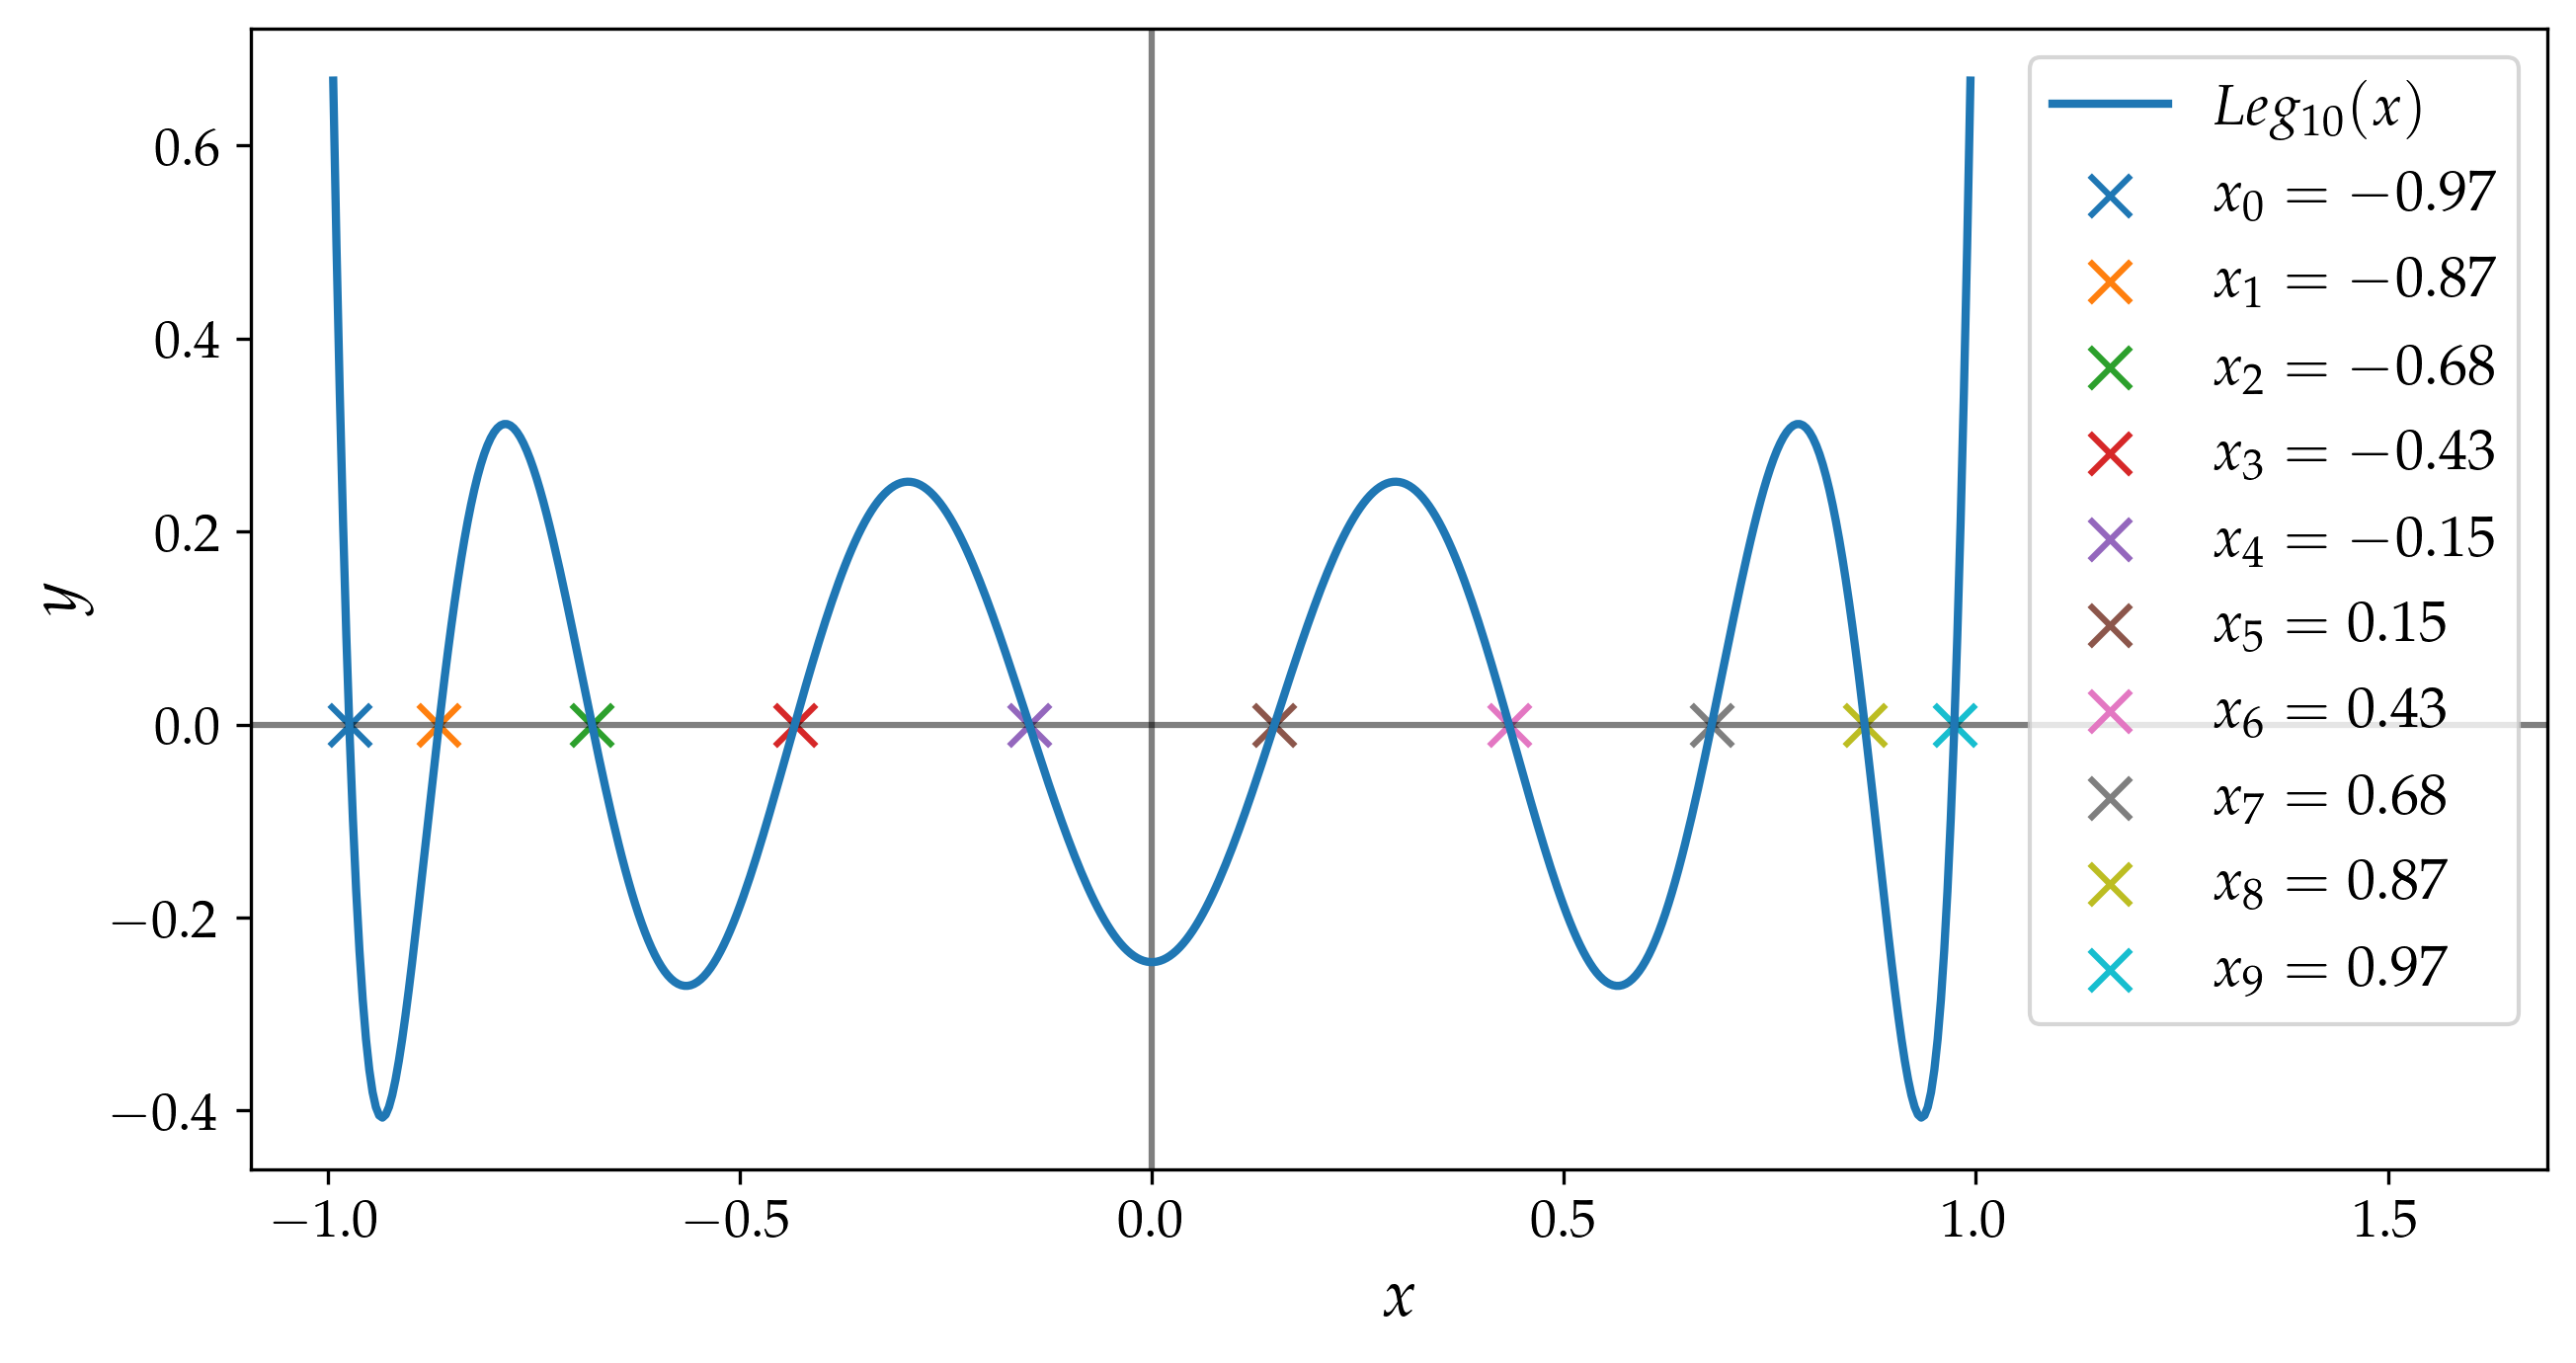

In [83]:
# plot funcs
limx = max(eigs_leg)*1.02
xcoo = np.linspace(-limx, limx, 500, dtype=float)
ycoo = leg_10(xcoo)
plt.figure(figsize=(10,5))
plt.axhline(0, color='black', linewidth=1.5, alpha=0.5)
plt.axvline(0, color='black', linewidth=1.5, alpha=0.5)
plt.plot(xcoo, ycoo, lw=2, label=r'$Leg_{10}(x)$')

n_roots = len(eigs_leg)
cmap = plt.get_cmap('tab20') 
for n_eig, lamb in enumerate(eigs_leg):
    color_n = cmap(n_eig / n_roots)
    plt.scatter(lamb, 0, label=rf'$x_{n_eig} = {lamb:.2f}$', marker='x', s=100, color=color_n)

plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.xlim(min(xcoo)-0.1, max(xcoo)+0.7)

plt.legend()
plt.savefig('plots/Leg_root')
plt.show()

In [84]:
import numpy as np
c_h6 = (np.array([-120, 0, 720, 0, -480, 0, 64]))
her_6 = lambda x: np.dot(c_h6, np.array([x**n for n in np.arange(len(c_h6))]))
eigs_her = root_finder(np.flip(c_h6))

print("Roots Hermite 6:", eigs_her)

Roots Hermite 6: [-2.35060497 -1.33584907 -0.43607741  0.43607741  1.33584907  2.35060497]


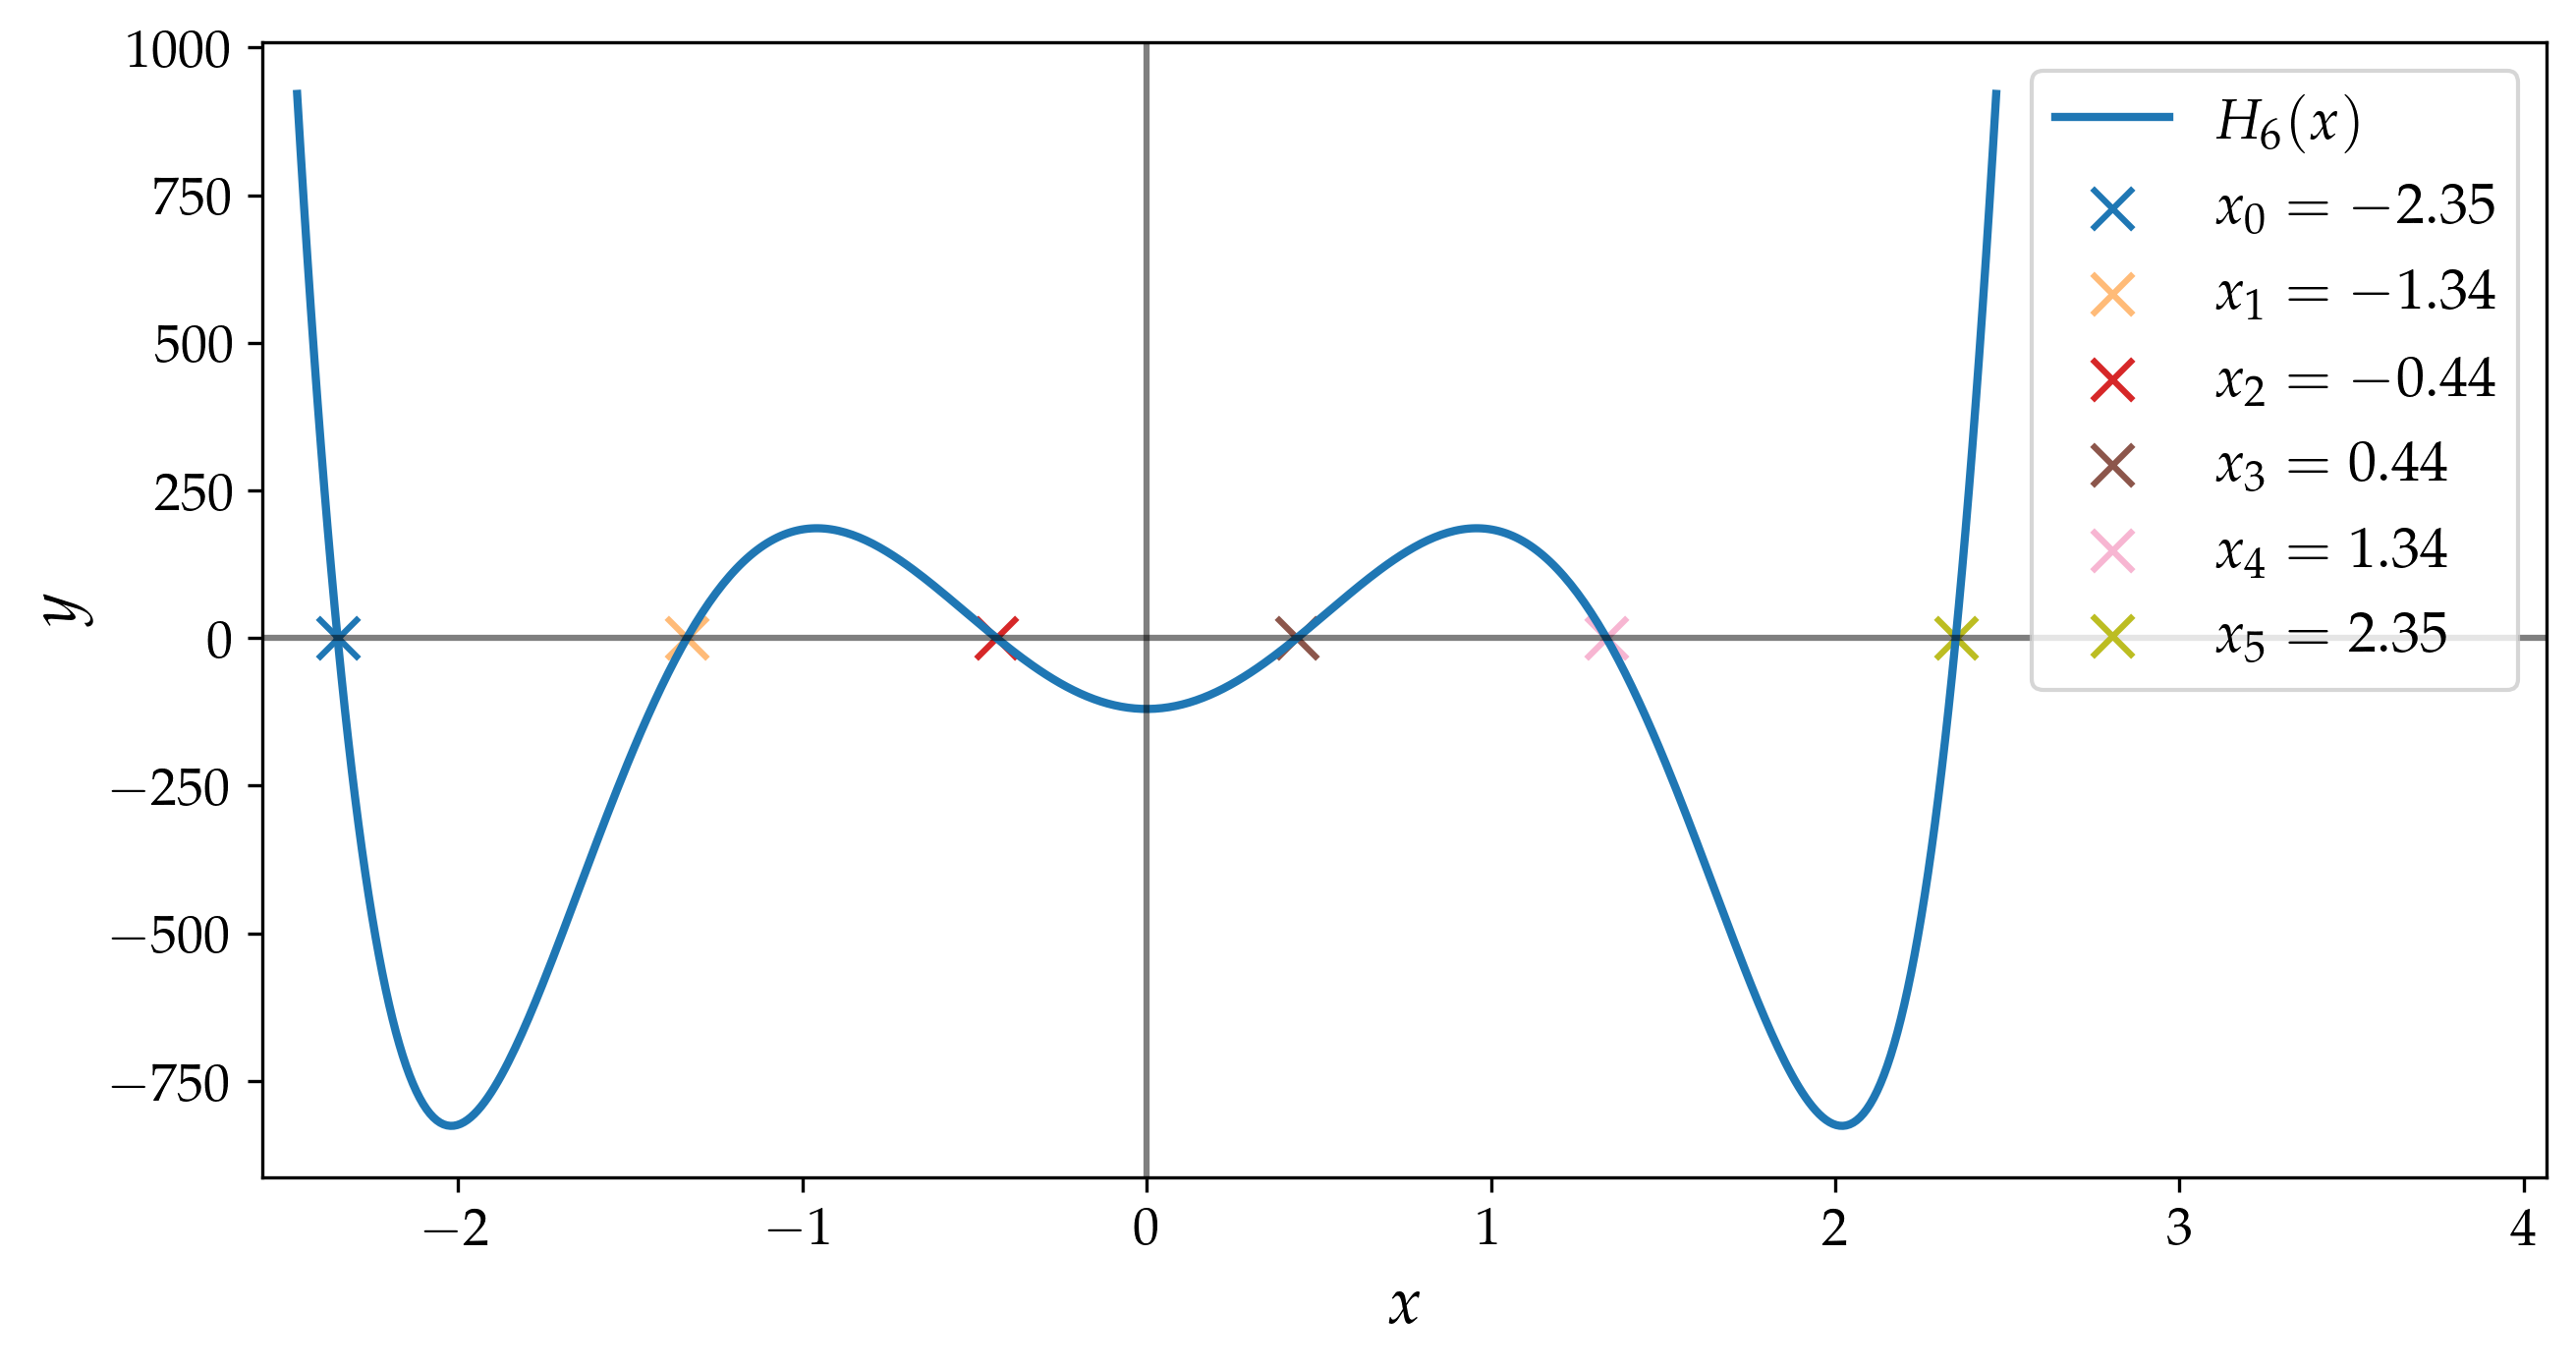

In [85]:
# plot funcs
limx = max(eigs_her)*1.05
xcoo = np.linspace(-limx, limx, 500, dtype=float)
ycoo = her_6(xcoo)
plt.figure(figsize=(10,5))
plt.plot(xcoo, ycoo, lw=2, label=r'$H_{6}(x)$')

n_roots = len(eigs_her)
cmap = plt.get_cmap('tab20') 
for n_eig, lamb in enumerate(eigs_her):
    color_n = cmap(n_eig / n_roots)
    plt.scatter(lamb, 0, label=rf'$x_{n_eig} = {lamb:.2f}$', marker='x', s=100, color=color_n)

plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.xlim(min(xcoo)-0.1, max(xcoo)+1.6)

plt.axhline(0, color='black', linewidth=1.5, alpha=0.5)
plt.axvline(0, color='black', linewidth=1.5, alpha=0.5)
plt.legend()
plt.savefig('plots/Her_root')
plt.show()

In [86]:
def herm_coeff(n):
    if n == 0:
        return np.array([1])
    if n == 1:
        return np.array([2, 0])
    
    h_minus_1 = np.array([1])   # H0
    h_n = np.array([0, 2])      # H1
    
    for i in range(1, n):
        term1 = 2 * np.insert(h_n, 0, 0) 
        term2 = 2 * i * np.append(h_minus_1, [0, 0])
        h_next = term1 - term2
        h_minus_1 = h_n
        h_n = h_next
        
    return np.flip(h_n)

eigs_gen = root_finder(herm_coeff(6))
diff = np.sum((eigs_gen - eigs_her)**2)
print('diff =', diff)


diff = 3.47573856774679e-23
